<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Portfolio Project: Laptop Market Exploratory Data Analysis
**Data Science Portfolio — IBM Professional Certificate Projects | Module 3: Exploratory Data Analysis**

### 👨‍💻 Executive Summary
This notebook demonstrates the use of exploratory data analysis applied to a laptop pricing dataset. With the visualization of feature patterns (continuous and categorical), Pearson Correlation Coefficient, p-value, descriptive statistical analysis, GroupBy, and pivot tables we are able to get a good idea of the data before proceeding with the modeling phase. 

The insights gained here regarding feature significance directly inform the feature selection for the [Predictive Modeling Notebook](https://github.com/rcastro-ai/IBM-Data-Science-Professional-Certificate/blob/main/07-Data-Analysis-with-Python/Laptop-Price-Predictive-Modeling.ipynb).

---
*Original lab framework provided by IBM Skills Network. Technical implementation, 
statistical analysis, and model interpretation performed by [Roberto Castro/rcastro-ai](https://github.com/rcastro-ai)*

# **Hands-on lab: Exploratory Data Analysis - Laptops Pricing dataset**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired throughout the module, to explore the effect of different features on the price of laptops. 


# Objectives

After completing this lab you will be able to:

 - Visualize individual feature patterns
 - Run descriptive statistical analysis on the dataset
 - Use groups and pivot tables to find the effect of categorical variables on price
 - Use Pearson Correlation to measure the interdependence between variables


# Setup


For this lab, we will be using the following libraries:

* `skillsnetwork` for downloading the data
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`scipy`](https://docs.scipy.org/doc/scipy/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for statistical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


# Install Required Libraries

You can install the required libraries by simply running the `pip install` command with a `%` sign before it. For this environment, `seaborn` library requires installation.


In [1]:
# Installing needed libraries (If using Pyodide)

#import piplite
#await piplite.install('seaborn')

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [2]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

# Import the dataset

You should download the modified version of the data set from the last module. 
Run the following code block to download the CSV file to this environment.


The functions below will download the dataset into your browser:


In [3]:
# If running from a browser

#from pyodide.http import pyfetch

# Defining method to download a file

#async def download(url, filename):
#    response = await pyfetch(url)
#    if response.status == 200:
#        with open(filename, "wb") as f:
#            f.write(await response.bytes())

In [4]:
# Storing URL value in a variable

filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
file_name = "laptops-m3.csv"

In [5]:
# Downloading the file (if running from the web)

#await download(filepath, file_name)


Import the file to a pandas dataframe.


In [6]:
# Importing data from downloaded file into a dataframe indicating that row 0 contains the headers

#df = pd.read_csv(file_name, header=0)

> Note: This version of the lab is working on JupyterLite, which requires the dataset to be downloaded to the interface. While working on the downloaded version of this notebook on their local machines, the learners can simply **skip the steps above**, and simply use the URL directly in the `pandas.read_csv()` function. You can uncomment and run the statements in the cell below.


In [7]:
# Using this code for local version (Anaconda, for example)

# Loading data into dataframe
df = pd.read_csv(filepath, header=0) # Dataset has headers in row 0

Print the first 5 entries of the dataset to confirm loading.


In [8]:
# Browsing the first 5 rows of the dataframe

df.head(10)

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0
5,5,5,Dell,3,1,1,5,15.6,0.551724,8,256,4.85100,1016,Low,1,0
6,6,6,HP,3,3,1,5,15.6,0.551724,8,256,4.63050,1117,Low,1,0
7,7,7,Acer,3,2,1,5,15.0,0.551724,4,256,4.85100,866,Low,0,1
8,8,8,Dell,3,1,1,5,15.6,0.862069,4,256,5.07150,812,Low,1,0
9,9,9,Acer,3,3,1,7,15.0,0.620690,8,256,4.85100,1068,Low,0,1


# Task 1 - Visualize individual feature patterns

### Continuous valued features
Generate regression plots for each of the parameters "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price". Also, print the value of correlation of each feature with "Price".


In [9]:
# Showing data types of all columns in dataframe

df.dtypes

Unnamed: 0.1          int64
Unnamed: 0            int64
Manufacturer         object
Category              int64
GPU                   int64
OS                    int64
CPU_core              int64
Screen_Size_inch    float64
CPU_frequency       float64
RAM_GB                int64
Storage_GB_SSD        int64
Weight_pounds       float64
Price                 int64
Price-binned         object
Screen-Full_HD        int64
Screen-IPS_panel      int64
dtype: object

The Pearson Correlation Coefficient is 0.3666655589258861  with a P-value of P =  5.5024633507134225e-09


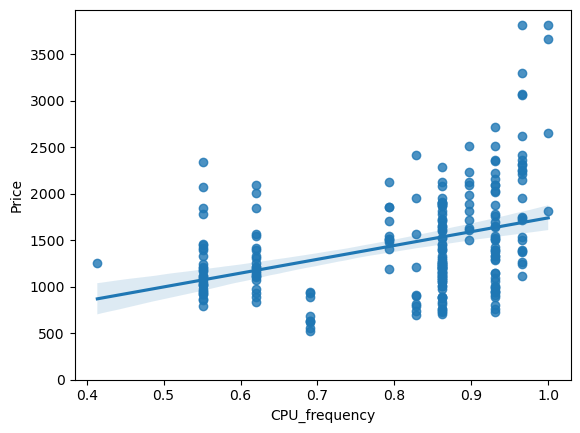

In [10]:
# Creating scatterplot for CPU_frequency and Price to see CPU_frequency as a potential predictor of variable price

# Generate scatterplot
sns.regplot(x="CPU_frequency", y="Price", data=df)
plt.ylim(0,)

# Get correlation information
pearson_coef, p_value = stats.pearsonr(df['CPU_frequency'], df['Price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value ) 

<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="CPU_frequency", y="Price", data=df)
plt.ylim(0,)
```

</details>


The Pearson Correlation Coefficient is -0.1106442081711827  with a P-value of P =  0.08853397846830766


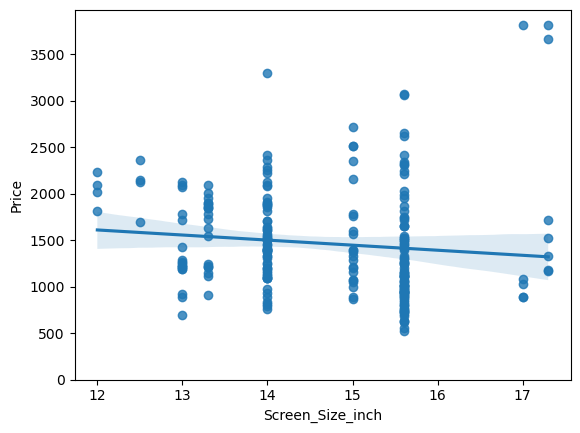

In [11]:
# Creating scatterplot for Screen_Size_inch and Price to see CPU_frequency as a potential predictor of variable price

# Generate scatterplot
sns.regplot(x="Screen_Size_inch", y="Price", data=df)
plt.ylim(0,)

# Get correlation information
pearson_coef, p_value = stats.pearsonr(df['Screen_Size_inch'], df['Price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value ) 


<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="Screen_Size_inch", y="Price", data=df)
plt.ylim(0,)
```

</details>


The Pearson Correlation Coefficient is -0.050312258377515476  with a P-value of P =  0.43976938534338944


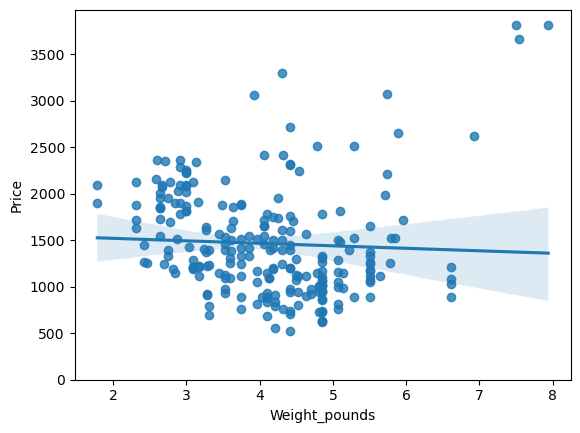

In [12]:
# Creating scatterplot for Weight_pounds and Price to see CPU_frequency as a potential predictor of variable price

# Generate scatterplot
sns.regplot(x="Weight_pounds", y="Price", data=df)
plt.ylim(0,)

# Get correlation information
pearson_coef, p_value = stats.pearsonr(df['Weight_pounds'], df['Price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value ) 


<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="Weight_pounds", y="Price", data=df)
plt.ylim(0,)
```

</details>


In [13]:
# Showing the correlation values for all three variables with Price

for variable in ['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds']:
    pearson_coef, p_value = stats.pearsonr(df[variable], df['Price'])
    print(f"The Pearson Correlation Coefficient of Price and {variable} is", pearson_coef, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient of Price and CPU_frequency is 0.3666655589258861  with a P-value of P =  5.5024633507134225e-09
The Pearson Correlation Coefficient of Price and Screen_Size_inch is -0.1106442081711827  with a P-value of P =  0.08853397846830766
The Pearson Correlation Coefficient of Price and Weight_pounds is -0.050312258377515476  with a P-value of P =  0.43976938534338944


<details>
    <summary>Click here for Solution</summary>

```python
for param in ["CPU_frequency", "Screen_Size_inch","Weight_pounds"]:
    print(f"Correlation of Price and {param} is ", df[[param,"Price"]].corr())
```

</details>


Interpretation: "CPU_frequency" has a 36% positive correlation with the price of the laptops. The other two parameters have weak correlation with price.


### Categorical features
Generate Box plots for the different feature that hold categorical values. These features would be "Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"


<Axes: xlabel='Category', ylabel='Price'>

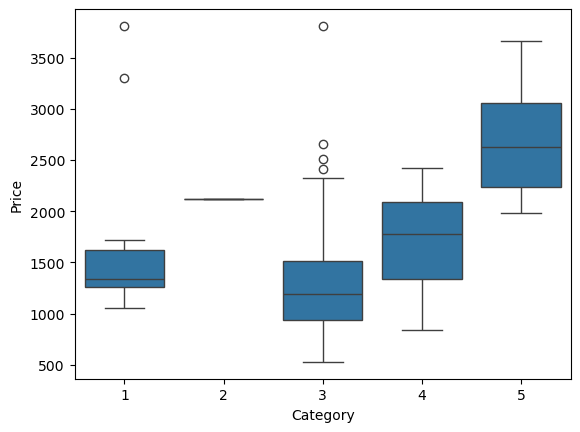

In [14]:
# Finding the relationship between Category and Price using a boxplot

sns.boxplot(x="Category", y="Price", data=df)


<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="Category", y="Price", data=df)
```

</details>


<Axes: xlabel='GPU', ylabel='Price'>

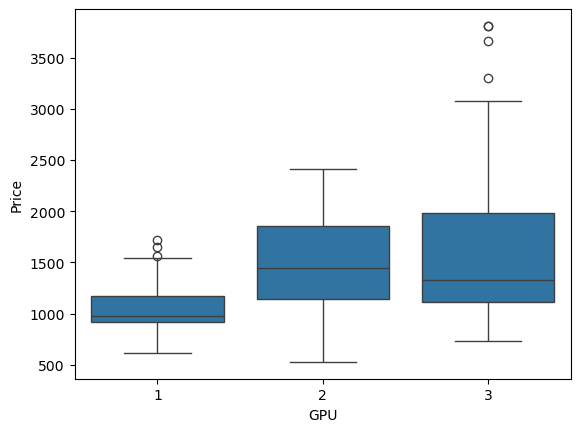

In [15]:
# Finding the relationship between GPU and Price using a boxplot

sns.boxplot(x="GPU", y="Price", data=df)


<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="GPU", y="Price", data=df)
```

</details>


<Axes: xlabel='OS', ylabel='Price'>

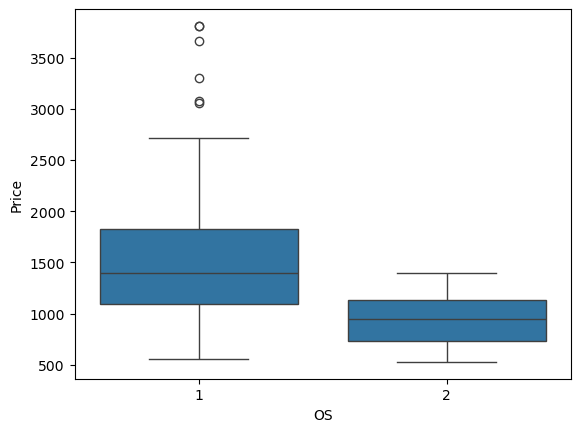

In [16]:
# Finding the relationship between OS and Price using a boxplot

sns.boxplot(x="OS", y="Price", data=df)

<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="OS", y="Price", data=df)
```

</details>


<Axes: xlabel='CPU_core', ylabel='Price'>

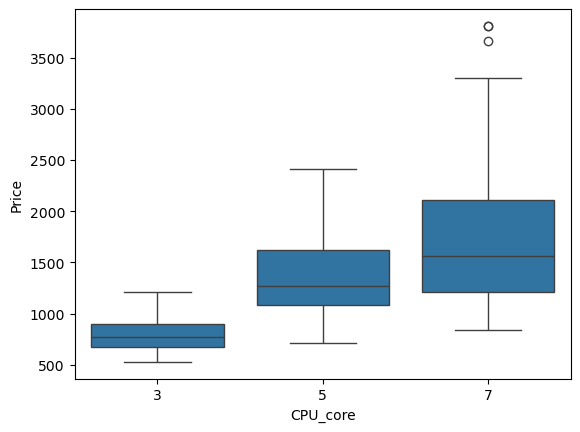

In [17]:
# Finding the relationship between CPU_core and Price using a boxplot

sns.boxplot(x="CPU_core", y="Price", data=df)

<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="CPU_core", y="Price", data=df)
```

</details>


<Axes: xlabel='RAM_GB', ylabel='Price'>

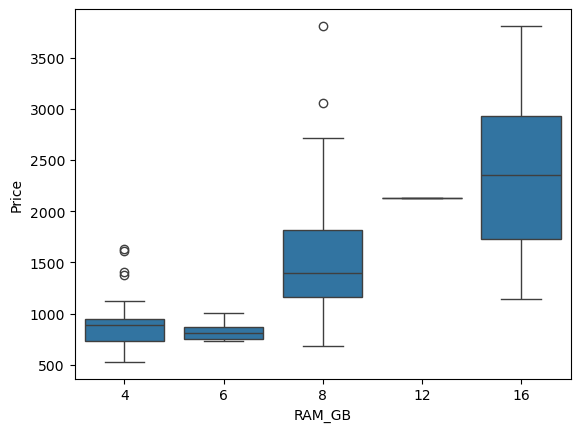

In [18]:
# Finding the relationship between RAM_GB and Price using a boxplot

sns.boxplot(x="RAM_GB", y="Price", data=df)

<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="RAM_GB", y="Price", data=df)
```

</details>


<Axes: xlabel='Storage_GB_SSD', ylabel='Price'>

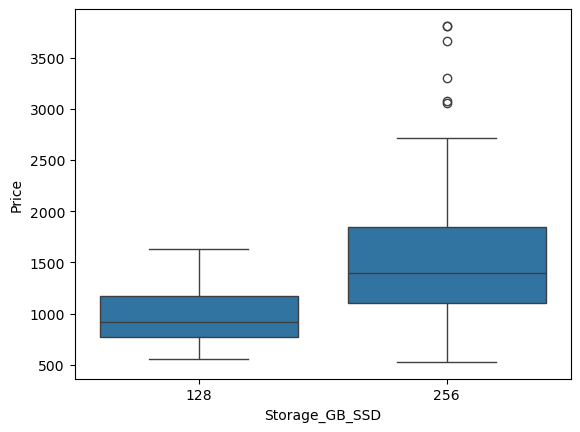

In [19]:
# Finding the relationship between Storage_GB_SSD and Price using a boxplot

sns.boxplot(x="Storage_GB_SSD", y="Price", data=df)

<details>
    <summary>Click here for Solution</summary>
    
```python
sns.boxplot(x="Storage_GB_SSD", y="Price", data=df)
```

</details>


# Task 2 - Descriptive Statistical Analysis


Generate the statistical description of all the features being used in the data set. Include "object" data types as well.


In [20]:
# Showing descriptive statistics analysis

print(df.describe())
print(df.describe(include=['object']))

       Unnamed: 0.1  Unnamed: 0    Category         GPU          OS  \
count    238.000000  238.000000  238.000000  238.000000  238.000000   
mean     118.500000  118.500000    3.205882    2.151261    1.058824   
std       68.848868   68.848868    0.776533    0.638282    0.235790   
min        0.000000    0.000000    1.000000    1.000000    1.000000   
25%       59.250000   59.250000    3.000000    2.000000    1.000000   
50%      118.500000  118.500000    3.000000    2.000000    1.000000   
75%      177.750000  177.750000    4.000000    3.000000    1.000000   
max      237.000000  237.000000    5.000000    3.000000    2.000000   

         CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
count  238.000000        238.000000     238.000000  238.000000   
mean     5.630252         14.688655       0.813822    7.882353   
std      1.241787          1.166045       0.141860    2.482603   
min      3.000000         12.000000       0.413793    4.000000   
25%      5.000000         14.0

<details>
<summary>Click here for Solution</summary>

```python
print(df.describe())
print(df.describe(include=['object']))
```

</details>


# Task 3 - GroupBy and Pivot Tables

Group the parameters "GPU", "CPU_core" and "Price" to make a pivot table and visualize this connection using the pcolor plot.


In [21]:
# Grouping variables 'drive-wheels', 'body-style' and 'price'

# Creating the group with 'GPU','CPU_core', and 'Price'
df_group_one = df[['GPU','CPU_core','Price']]

# Grouping results to get average price for each type of drive wheels
df_grouped = df_group_one.groupby(['GPU', 'CPU_core'], as_index=False).mean()
df_grouped


,GPU,CPU_core,Price
0,1,3,769.250000
1,1,5,998.500000
2,1,7,1167.941176
3,2,3,785.076923
4,2,5,1462.197674
5,2,7,1744.621622
6,3,3,784.000000
7,3,5,1220.680000
8,3,7,1945.097561


<details>
<summary>Click here for Solution</summary>

```python
df_gptest = df[['GPU','CPU_core','Price']]
grouped_test1 = df_gptest.groupby(['GPU','CPU_core'],as_index=False).mean()
print(grouped_test1)
```

</details>


In [22]:
# Showing the data in a pivot table to make it easier to understand

grouped_pivot = df_grouped.pivot(index='GPU',columns='CPU_core')
grouped_pivot

Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561

<details>
<summary>Click here for Solution</summary>

```python
grouped_pivot = grouped_test1.pivot(index='GPU',columns='CPU_core')
print(grouped_pivot)
```

</details>


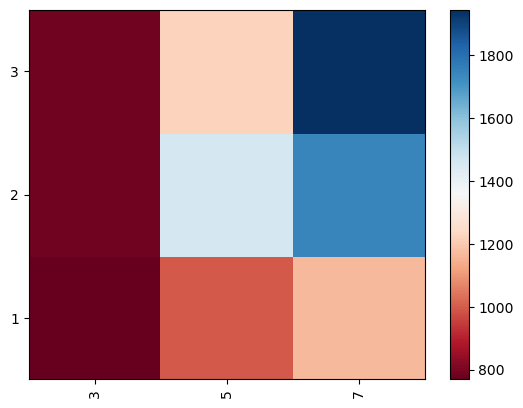

In [23]:
# Creating the plot

# Importing pyplot
import matplotlib.pyplot as plt
%matplotlib inline 

# Creating a heatmap for the grouped results in dataframe grouped_pivot
#plt.pcolor(grouped_pivot, cmap='RdBu')
#plt.colorbar()
#plt.show()

# Creating a heatmap for the grouped results in dataframe grouped_pivot
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

# label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

# Move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

# Insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

# Rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

<details>
<summary>Click here for Solution</summary>

```python
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

fig.colorbar(im)
```

</details>


# Task 4 - Pearson Correlation and p-values

Use the `scipy.stats.pearsonr()` function to evaluate the Pearson Coefficient and the p-values for each parameter tested above. This will help you determine the parameters most likely to have a strong effect on the price of the laptops.


In [24]:
# Showing the correlation values for variables 'RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_inch','Weight_pounds','CPU_core','OS','GPU', and 'Category' with Price

for variable in ['RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_inch','Weight_pounds','CPU_core','OS','GPU','Category']:
    pearson_coef, p_value = stats.pearsonr(df[variable], df['Price'])
    print(f"The Pearson Correlation Coefficient of Price and {variable} is", pearson_coef, " with a P-value of P = ", p_value) 


The Pearson Correlation Coefficient of Price and RAM_GB is 0.5492972971857841  with a P-value of P =  3.6815606288429613e-20
The Pearson Correlation Coefficient of Price and CPU_frequency is 0.3666655589258861  with a P-value of P =  5.5024633507134225e-09
The Pearson Correlation Coefficient of Price and Storage_GB_SSD is 0.24342075521810297  with a P-value of P =  0.00014898923191724174
The Pearson Correlation Coefficient of Price and Screen_Size_inch is -0.1106442081711827  with a P-value of P =  0.08853397846830766
The Pearson Correlation Coefficient of Price and Weight_pounds is -0.050312258377515476  with a P-value of P =  0.43976938534338944
The Pearson Correlation Coefficient of Price and CPU_core is 0.45939777733551157  with a P-value of P =  7.912950127009034e-14
The Pearson Correlation Coefficient of Price and OS is -0.22172980114827384  with a P-value of P =  0.0005696642559246749
The Pearson Correlation Coefficient of Price and GPU is 0.2882981988881427  with a P-value of P

<details>
<summary>Click here for Solution</summary>

```python
for param in ['RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_inch','Weight_pounds','CPU_core','OS','GPU','Category']:
    pearson_coef, p_value = stats.pearsonr(df[param], df['Price'])
    print(param)
    print("The Pearson Correlation Coefficient for ",param," is", pearson_coef, " with a P-value of P =", p_value)
```

</details>


# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


Copyright © 2023 IBM Corporation. All rights reserved.


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-15|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-18|0.2|Vicky Kuo|Reviewed and Revised|--!>
